<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/unsupervised/dimensionality_reduction/experiment_autoencoder_dimensionality_reduction_mnist_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Autoencoder

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense
)

Load Dataset

In [ ]:
(X_train, _), (X_test, _) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Normalize Images

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0

Flatten Images

Original:

28 × 28

Flattened:

784 Features

In [ ]:
X_train = X_train.reshape(
    -1,
    784
)

X_test = X_test.reshape(
    -1,
    784
)

Define Dimensions

Compression:

784 → 32

In [ ]:
input_dim = 784

encoding_dim = 32

Build Encoder

In [ ]:
input_layer = Input(shape=(784,))

encoded = Dense(
    128,
    activation="relu"
)(input_layer)

encoded = Dense(
    64,
    activation="relu"
)(encoded)

latent = Dense(
    32,
    activation="relu"
)(encoded)

Build Decoder

In [ ]:
decoded = Dense(
    64,
    activation="relu"
)(latent)

decoded = Dense(
    128,
    activation="relu"
)(decoded)

output_layer = Dense(
    784,
    activation="sigmoid"
)(decoded)

Create Autoencoder Model

In [ ]:
autoencoder = Model(
    input_layer,
    output_layer
)

Create Encoder Model Separately

This extracts compressed features.

In [ ]:
encoder = Model(
    input_layer,
    latent
)

Compile Autoencoder

In [ ]:
autoencoder.compile(

    optimizer="adam",

    loss="binary_crossentropy"
)

Train Autoencoder

Input = Output

In [ ]:
history = autoencoder.fit(

    X_train,
    X_train,

    validation_data=(
        X_test,
        X_test
    ),

    epochs=20,

    batch_size=256
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3834 - val_loss: 0.3196
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3100 - val_loss: 0.3066
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3018 - val_loss: 0.3013
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2973 - val_loss: 0.2976
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2945 - val_loss: 0.2952
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2921 - val_loss: 0.2933
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2905 - val_loss: 0.2917
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2889 - val_loss: 0.2903
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2876 - val_loss: 0.2890
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2863 - val_loss: 0.2884
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2854 - val_loss: 0.2871
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

Compress Data

In [ ]:
compressed_features = encoder.predict(
    X_test
)

print(compressed_features.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 32)


Reconstruct Images

In [ ]:
reconstructed = autoencoder.predict(
    X_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Visualize Original vs Reconstructed

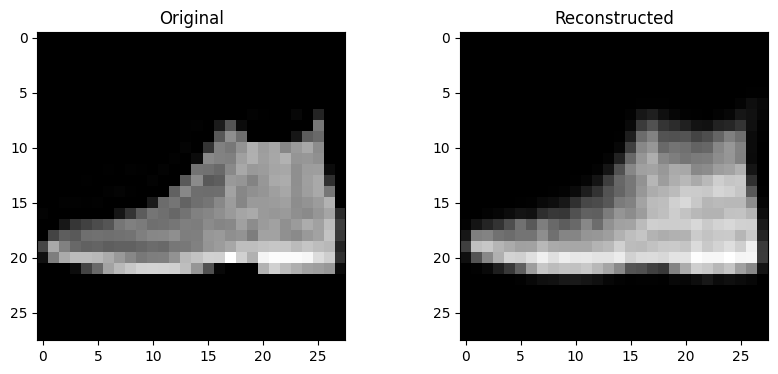

In [ ]:
plt.figure(figsize=(10, 4))

# Original
plt.subplot(1, 2, 1)

plt.imshow(
    X_test[0].reshape(28, 28),
    cmap="gray"
)

plt.title("Original")

# Reconstructed
plt.subplot(1, 2, 2)

plt.imshow(
    reconstructed[0].reshape(28, 28),
    cmap="gray"
)

plt.title("Reconstructed")

plt.show()

## Real Industry Applications

| Domain        | Autoencoder Use        |
|---------------|------------------------|
| Cybersecurity | anomaly detection      |
| Healthcare    | tumor anomaly detection|
| Finance       | fraud detection        |
| Vision        | image compression      |
| NLP           | embedding learning     |
| Recommendation| latent representations |


## Autoencoder vs PCA

| Feature               | PCA | Autoencoder |
|-----------------------|-----|-------------|
| Linear                | ✅   | ❌          |
| Nonlinear Learning    | ❌   | ✅          |
| Deep Learning         | ❌   | ✅          |
| Complex Feature Learning | ❌   | ✅          |
| Scalability           | Medium | High        |
